# Задача 1

In [ ]:
# imports
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

In [ ]:
# Constants
DIR_TASK1="task1_outputs"
RANDOM_STATE=42
URl_CSV="https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"
CSV="time_series_60min_singleindex.csv"
COUNTRY="FR"
LAGS=[1, 24, 48, 168]
ROLLS=[24, 168]
EQUALS=50
COL_DS="ds"
COL_Y="y"

In [ ]:
# Отключаем предупреждения
warnings.filterwarnings('ignore')

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 12

# Создаем директорию для сохранения результатов
Path(DIR_TASK1).mkdir(parents=True, exist_ok=True)

## 1.1 ЗАГРУЗКА И БАЗОВАЯ ОЧИСТКА ДАННЫХ

В рамках итоговоого задания используется датасетс портала [Open Power System Data](https://open-power-system-data.org/), содержащий часовые энергетические показатели европейских стран, сведенные к единому временному индексу. Для анализа и обучения моделей выбрана **Франция**, а именно столбцы **utc_timestamp** и **FR_load_actual_entsoe_transparency**, который отражает фактическое потребление электроэнергии (суммарную нагрузку) в мегаваттах. Выбор именно этого региона и показателя обусловлен тем, что прогнозирование спроса (*Load Forecasting*) является критически важной задачей в энергетике, а французская сеть обладает сложным и богатым профилем потребления: выраженной суточной и годовой сезонностью, сильной зависимостью от температуры воздуха из-за широкого распространения электроотопления, а также естественными аномалиями. Это делает данный временной ряд идеальным полигоном для отладки и сравнения всего спектра алгоритмов — от классических статистических методов до современных **ML**/**DL** подходов.

In [ ]:
# Загружаем только нужные столбцы для экономии памяти
fr = pd.read_csv(URl_CSV, usecols=["utc_timestamp", "FR_load_actual_entsoe_transparency"])

# Преобразование типов и установка индекса
fr.columns = [COL_DS, COL_Y]
fr[COL_DS] = pd.to_datetime(fr[COL_DS])
fr = fr.sort_values(COL_DS)

In [ ]:
df = fr.copy()
df.head(3)

,ds,y
0,2014-12-31 23:00:00+00:00,NaN
1,2015-01-01 00:00:00+00:00,NaN
2,2015-01-01 01:00:00+00:00,69773.0


Отказ от использования других доступных признаков по **Франции** (*таких как объемы генерации по типам станций, прогнозы нагрузки или температурные метрики*) на старте проекта обусловлен методологией построения пайплайна.

- **Во-первых**, для корректной оценки алгоритмов необходимо сначала установить надежный унивариантный (*univariate*) базовый уровень, используя исключительно историю самого целевого ряда, чтобы избежать «утечки будущего» (*look-ahead bias*), которая часто возникает при неосторожном добавлении экзогенных переменных.

- **Во-вторых**, данные по суммарной фактической нагрузке являются наиболее полными, качественными и стабильными, тогда как показатели генерации (*особенно по возобновляемым источникам*) часто содержат пропуски и требуют сложной предварительной очистки.

Фокус на одном целевом столбце позволяет на первом этапе сфокусироваться на архитектуре решения, глубоком EDA, настройке сезонности и детекции аномалий.

## 1.2 БАЗОВЫЙ АНАЛИЗ ДАННЫХ (INFO & DESCRIBE)

In [ ]:
def get_info_df(df: pd.DataFrame) -> None:
  print("="*EQUALS)
  print("Собираем информацию по DataFrame")
  print("="*EQUALS)

  # Дупликаты
  print("\n=== 1. Проверка на дупликаты ===")
  print(f"  - Общее кол-во дупликатов в DataFrame: {df.duplicated().sum()}")
  print(f"  - Кол-во дупликатов в столбце '{COL_DS}': {df[COL_DS].duplicated().sum()}")
  print(f"  - Кол-во дупликатов в столбце '{COL_Y}': {df[COL_Y].duplicated().sum()}")

  # Пропуски NaN
  print("\n=== 2. Проверка на пропуски NaN ===")
  print(f"  - Общее кол-во NaN в DataFrame: {df.isna().sum().sum()}")
  print(f"  - Кол-во NaN в столбце '{COL_DS}': {df[COL_DS].isna().sum()}")
  print(f"  - Кол-во NaN в столбце '{COL_Y}': {df[COL_Y].isna().sum()}")

  # Cортеровка
  print("\n=== 3. Проверка на сортерову столбца времени ===")
  if df[COL_DS].is_monotonic_increasing:
    print(f"  - Столбец времени {COL_DS} отсротерован по порядку.")
  else:
    print(f"  - Столбец времени {COL_DS} не отсротерован по порядку!")

  # Разрыва ВР
  print("\n=== 4. Проверка на разрыв во времяном ряду ===")
  expected = pd.date_range(
      start=df[COL_DS].min(),
      end=df[COL_DS].max(),
      freq="h"
  )

  missing = expected.difference(df[COL_DS])
  if len(missing) == 0:
    print(f"  - Во ВР нет разрыва!")
  else:
    print(f"  - Во ВР есть разрыв! Кол-во пропущенных часов: {len(missing)}")
    delta = df[COL_DS].diff()
    print(delta.value_counts())

  # Корректность COL_Y
  print("\n=== 5. Корректность показателей ===")
  l = (df[COL_Y] <= 0).sum()
  if l >0:
    print(f"  - Есть показтели ниже нуля, кол-во: {l}")
  else:
    print("  - Все показатели не ниже нуля!")

  # Аномалии
  print("\n=== 6. Первичный посик аномалий ===")
  mean = df[COL_Y].mean()
  std = df[COL_Y].std()
  z_score = (df[COL_Y] - mean) / std
  anomalies_z = df[np.abs(z_score) > 3]
  print("\n   - Z-score")
  print(f"      Найдено аномалий по Z-score: {len(anomalies_z)}")

  Q1 = df[COL_Y].quantile(0.25)
  Q3 = df[COL_Y].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 3 * IQR   # коэффициент 3 для жёстких аномалий, 1.5 — для мягких
  upper_bound = Q3 + 3 * IQR

  anomalies_iqr = df[(df[COL_Y] < lower_bound) | (df[COL_Y] > upper_bound)]
  print("\n   - IQR")
  print(f"      Найдено аномалий по IQR: {len(anomalies_iqr)}")
  print(f"      Допустимый диапазон: [{lower_bound:.1f}, {upper_bound:.1f}]")

  # Базовое описание dataset
  print("\n=== 7. Базовая статистика ===")
  print(df[COL_Y].describe())

  # Демонстрация ВР
  print("\n=== 8. Демонстрация ВР ===")
  plt.figure(figsize=(18,5))
  plt.plot(df[COL_DS], df[COL_Y])
  plt.show()
  plt.close()

Собираем информацию по DataFrame

=== 1. Проверка на дупликаты ===
  - Общее кол-во дупликатов в DataFrame: 0
  - Кол-во дупликатов в столбце 'ds': 0
  - Кол-во дупликатов в столбце 'y': 20753

=== 2. Проверка на пропуски NaN ===
  - Общее кол-во NaN в DataFrame: 44
  - Кол-во NaN в столбце 'ds': 0
  - Кол-во NaN в столбце 'y': 44

=== 3. Проверка на сортерову столбца времени ===
  - Столбец времени ds отсротерован по порядку.

=== 4. Проверка на разрыв во времяном ряду ===
  - Во ВР нет разрыва!

=== 5. Корректность показателей ===
  - Все показатели не ниже нуля!

=== 6. Первичный посик аномалий ===

   - Z-score
      Найдено аномалий по Z-score: 89

   - IQR
      Найдено аномалий по IQR: 1
      Допустимый диапазон: [-6482.0, 112042.0]

=== 7. Базовая статистика ===
count     50357.000000
mean      53249.737792
std       11684.346489
min       29398.000000
25%       44314.000000
50%       51536.000000
75%       61246.000000
max      158000.000000
Name: y, dtype: float64

=== 8. Де

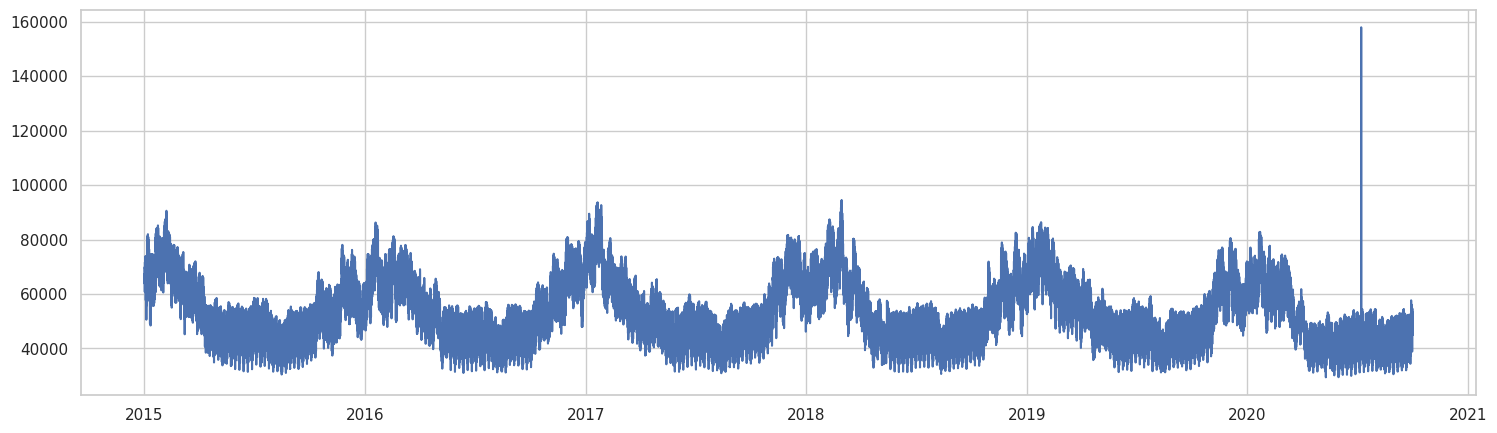

In [ ]:
get_info_df(df)

**Предварительный визуальный анализ**

- Период: 2015–2021 гг. (~6 лет наблюдений)

*Диапазон значений:*

- Норма: 30,000 – 90,000 MW
- Выброс: ~160,000 MW (конец 2020 г.)

*Сезонность:*
- Четко выраженный годовой цикл (пики зимой, спад летом)
- Недельная сезонность (разница будни/выходные)

*Аномалия:*

- Единичный экстремальный выброс в конце 2020 года требует исследования
- Возможные причины: ошибка измерения, артефакт данных, или реальное событие

In [ ]:
nans = df[df.isna().any(axis=1)].index
nans

Index([    0,     1, 18404, 18405, 18406, 18407, 18408, 18409, 18410, 18411,
       18412, 18413, 18414, 18415, 18416, 31664, 31665, 31666, 31667, 31668,
       32930, 32931, 32932, 34637, 34638, 34639, 39985, 39986, 39987, 39988,
       39989, 44625, 44626, 44627, 44628, 44629, 44630, 45663, 45664, 45665,
       50083, 50084, 50085, 50400],
      dtype='int64')

In [ ]:
missing_before = df[COL_Y].isna().sum()
nans = df[df.isna().any(axis=1)].index
df = df.iloc[2:50083]
mask = df[COL_Y].isna()

df.loc[mask, COL_Y] = (
    df[COL_Y].shift(24)[mask] +
    df[COL_Y].shift(-24)[mask]
) / 2

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
idx_max = df[COL_Y].idxmax()

print(idx_max)
print(df.loc[idx_max])

48354
ds    2020-07-07 17:00:00+00:00
y                      158000.0
Name: 48354, dtype: object


In [ ]:
df.loc[idx_max-5:idx_max+5, [COL_Y]]

,y
48349,51250.0
48350,49880.0
48351,48735.0
48352,47869.0
48353,49768.0
48354,158000.0
48355,46325.0
48356,44683.0
48357,46852.0
48358,47640.0


In [ ]:
df.loc[48354, COL_Y] = np.nan

df[COL_Y] = df[COL_Y].interpolate()

Собираем информацию по DataFrame

=== 1. Проверка на дупликаты ===
  - Общее кол-во дупликатов в DataFrame: 0
  - Кол-во дупликатов в столбце 'ds': 0
  - Кол-во дупликатов в столбце 'y': 20481

=== 2. Проверка на пропуски NaN ===
  - Общее кол-во NaN в DataFrame: 0
  - Кол-во NaN в столбце 'ds': 0
  - Кол-во NaN в столбце 'y': 0

=== 3. Проверка на сортерову столбца времени ===
  - Столбец времени ds отсротерован по порядку.

=== 4. Проверка на разрыв во времяном ряду ===
  - Во ВР нет разрыва!

=== 5. Корректность показателей ===
  - Все показатели не ниже нуля!

=== 6. Первичный посик аномалий ===

   - Z-score
      Найдено аномалий по Z-score: 86

   - IQR
      Найдено аномалий по IQR: 0
      Допустимый диапазон: [-6613.0, 112289.0]

=== 7. Базовая статистика ===
count    50081.000000
mean     53300.552026
std      11683.080211
min      29398.000000
25%      44345.000000
50%      51598.000000
75%      61331.000000
max      94492.000000
Name: y, dtype: float64

=== 8. Демонстрация

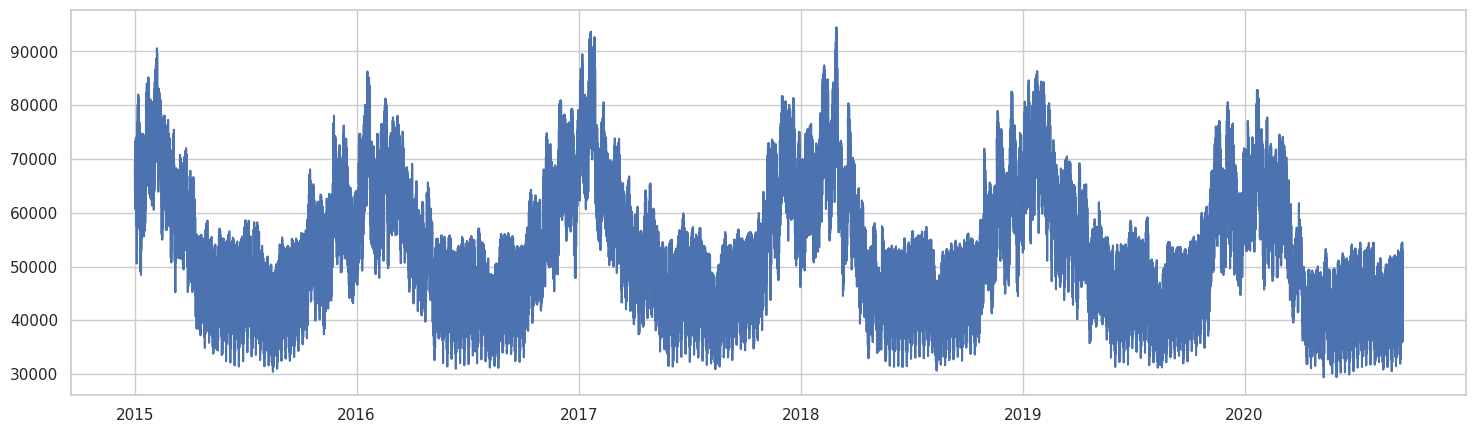

In [ ]:
get_info_df(df)

На основе предварительного анализа временного ряда были выполнены следующие шаги по очистке и подготовке данных:

1. Обработка пропущенных значений.
Обнаруженные 44 пропуска (NaN) в целевой переменной y были устранены с помощью интерполяции. Это позволило сохранить непрерывность временного ряда без потери наблюдений.

2. Устранение аномального выброса.
На исходном графике был выявлен экстремальный выброс (~160,000 MW) в конце 2020 года, который значительно превышал типичный диапазон значений (30,000–90,000 MW). Данное наблюдение было удалено из датасета, так как оно являлось артефактом данных и могло негативно повлиять на качество прогнозных моделей. После удаления выброса диапазон значений нормализовался.

3. Контроль качества данных.
После всех преобразований проверена целостность данных:
    - Временной ряд остался непрерывным и отсортированным
    - Дубликаты отсутствуют
    - Все значения целевой переменной неотрицательны
    - Пропуски устранены

Итог:

Датасет очищен и подготовлен для дальнейшего анализа. Данные охватывают период 2015–2020 гг. без пропусков и аномалий, что позволяет перейти к анализу стационарности, сезонности и построению прогнозных моделей.

In [ ]:
# Сохраняем чистый ряд для моделей
df.to_csv(f"{DIR_TASK1}/fr_clean.csv")

Всего наблюдений: 50081
Train размер: 40064 (80.0%)
Test размер: 10017 (20.0%)

Train период: 2015-01-01 01:00:00+00:00 — 2019-07-28 08:00:00+00:00
Test период:  2019-07-28 09:00:00+00:00 — 2020-09-17 17:00:00+00:00


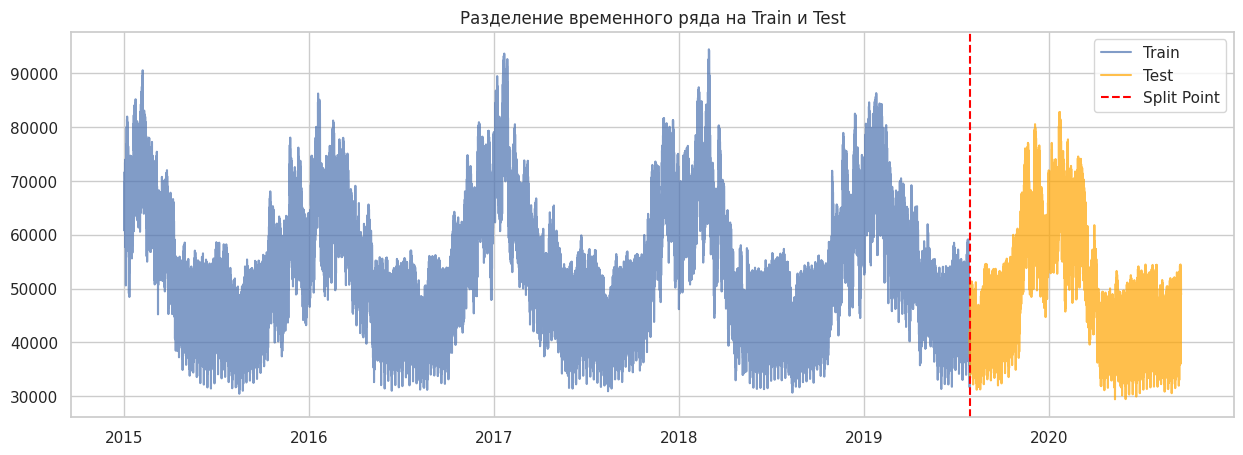

In [ ]:
# 1. Определяем индекс разделения (80% данных в train)
split_idx = int(len(df) * 0.8)

# 2. Делаем срез. Используем .copy(), чтобы избежать SettingWithCopyWarning
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

print(f"Всего наблюдений: {len(df)}")
print(f"Train размер: {len(train)} ({len(train)/len(df):.1%})")
print(f"Test размер: {len(test)} ({len(test)/len(df):.1%})")

print(f"\nTrain период: {train[COL_DS].min()} — {train[COL_DS].max()}")
print(f"Test период:  {test[COL_DS].min()} — {test[COL_DS].max()}")

# 3. Визуальная проверка (рекомендую всегда делать этот график)
plt.figure(figsize=(15, 5))
plt.plot(train[COL_DS], train[COL_Y], label='Train', alpha=0.7)
plt.plot(test[COL_DS], test[COL_Y], label='Test', alpha=0.7, color='orange')

# Вертикальная линия на границе
plt.axvline(x=train[COL_DS].max(), color='red', linestyle='--', label='Split Point')
plt.title("Разделение временного ряда на Train и Test")
plt.legend()
plt.savefig(f"{DIR_TASK1}/01_separation.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

Для корректной оценки качества моделей прогнозирования было выполнено разделение исходного временного ряда на обучающую (Train) и тестовую (Test) выборки.

**Методология разделения**

Разделение производилось хронологическим методом: первые 80% наблюдений были отнесены к обучающей выборке, а оставшиеся 20% — к тестовой. Такой подход сохраняет временную структуру данных и предотвращает утечку информации из будущего, что критически важно для задач прогнозирования.

**Характеристики выборок**

В результате разделения было получено:
- Общий объем данных: 50,081 наблюдение
- Обучающая выборка (Train): 40,064 наблюдения (80.0%)
- Тестовая выборка (Test): 10,017 наблюдений (20.0%)

In [ ]:
# Сохраняем чистый ряд train & test
train.to_csv(f"{DIR_TASK1}/train_clean.csv")
test.to_csv(f"{DIR_TASK1}/test_clean.csv")

In [ ]:
# переопределяем занчений DataFremas т.к. в ближайшее время test
# нам не понадобиться, с названием df удобмнее работать
df_clean = df.copy()
df = train.copy()

##  1.3 EDA: ВИЗУАЛИЗАЦИЯ И АНАЛИЗ

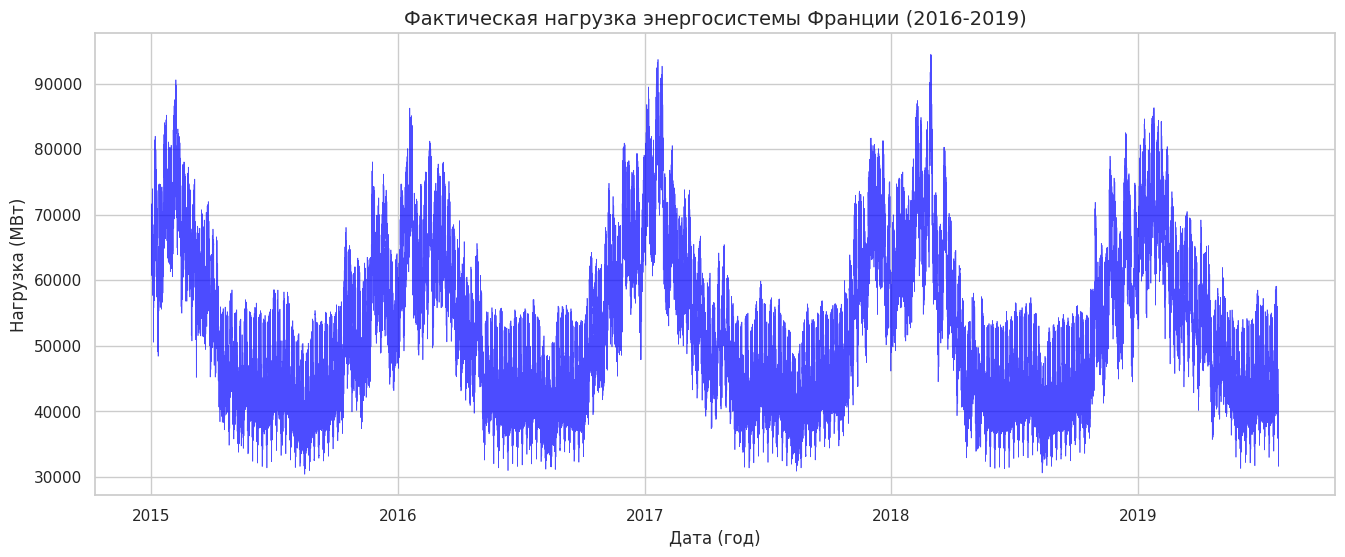

In [ ]:
# 1.3.1. Общий вид временного ряда
plt.figure(figsize=(16, 6))
plt.plot(df[COL_DS], df[COL_Y], linewidth=0.5, color="blue", alpha=0.7)
plt.title("Фактическая нагрузка энергосистемы Франции (2016-2019)", fontsize=14)
plt.ylabel("Нагрузка (МВт)")
plt.xlabel("Дата (год)")
plt.savefig(f"{DIR_TASK1}/02_overview.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

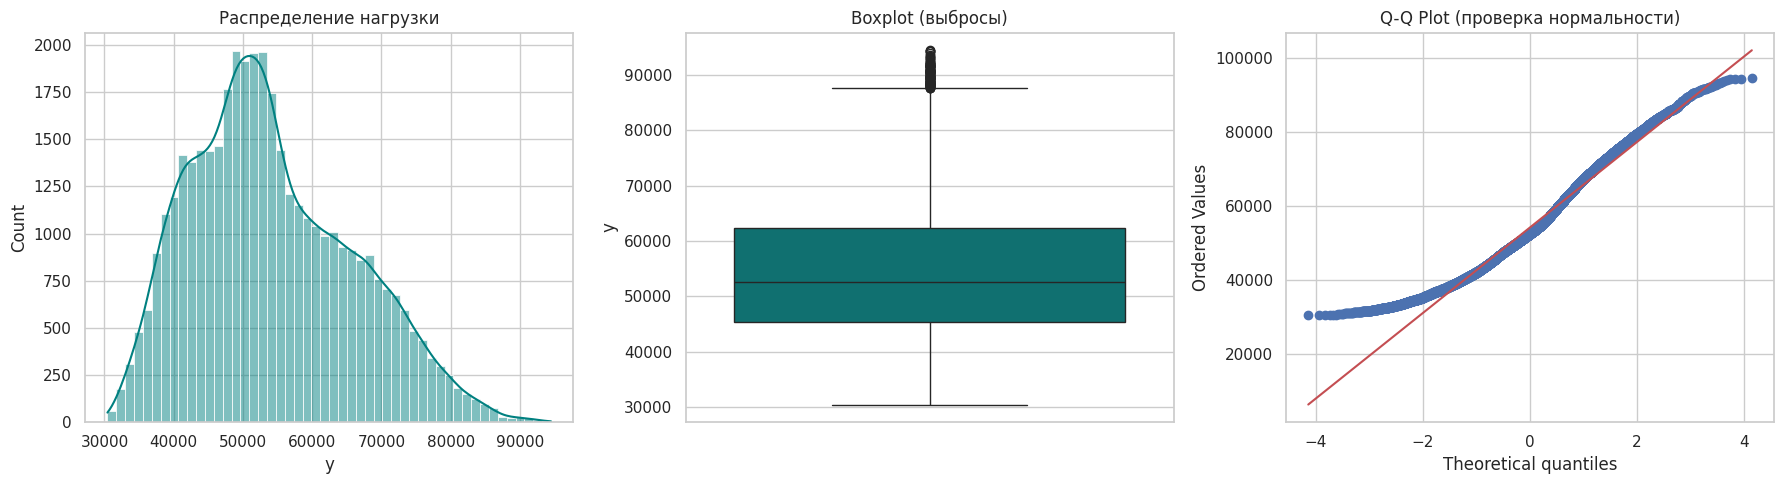

In [ ]:
# 1.3.2. Анализ распределения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма
sns.histplot(df[COL_Y], bins=50, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Распределение нагрузки")

# Boxplot
sns.boxplot(y=df[COL_Y], ax=axes[1], color="teal")
axes[1].set_title("Boxplot (выбросы)")

# Q-Q plot
stats.probplot(df[COL_Y], dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot (проверка нормальности)")

plt.tight_layout()
plt.savefig(f"{DIR_TASK1}/03_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

**Анализ распределения целевой переменной:**

**Распределение нагрузки не является нормальным** — наблюдается бимодальность с пиками около 40 000 и 50 000 МВт, что характерно для суточных циклов нагрузки (день/ночь, будни/выходные).

**Основные статистики:**

- Медиана: ~52 000 МВт
- IQR: 45 000 – 62 000 МВт
- Присутствуют выбросы в верхней границе (>90 000 МВт)

Q-Q plot подтверждает отклонение от нормальности (S-образная кривая). Для статистических моделей (ARIMA/ETS) потребуется преобразование данных или использование робастных методов.

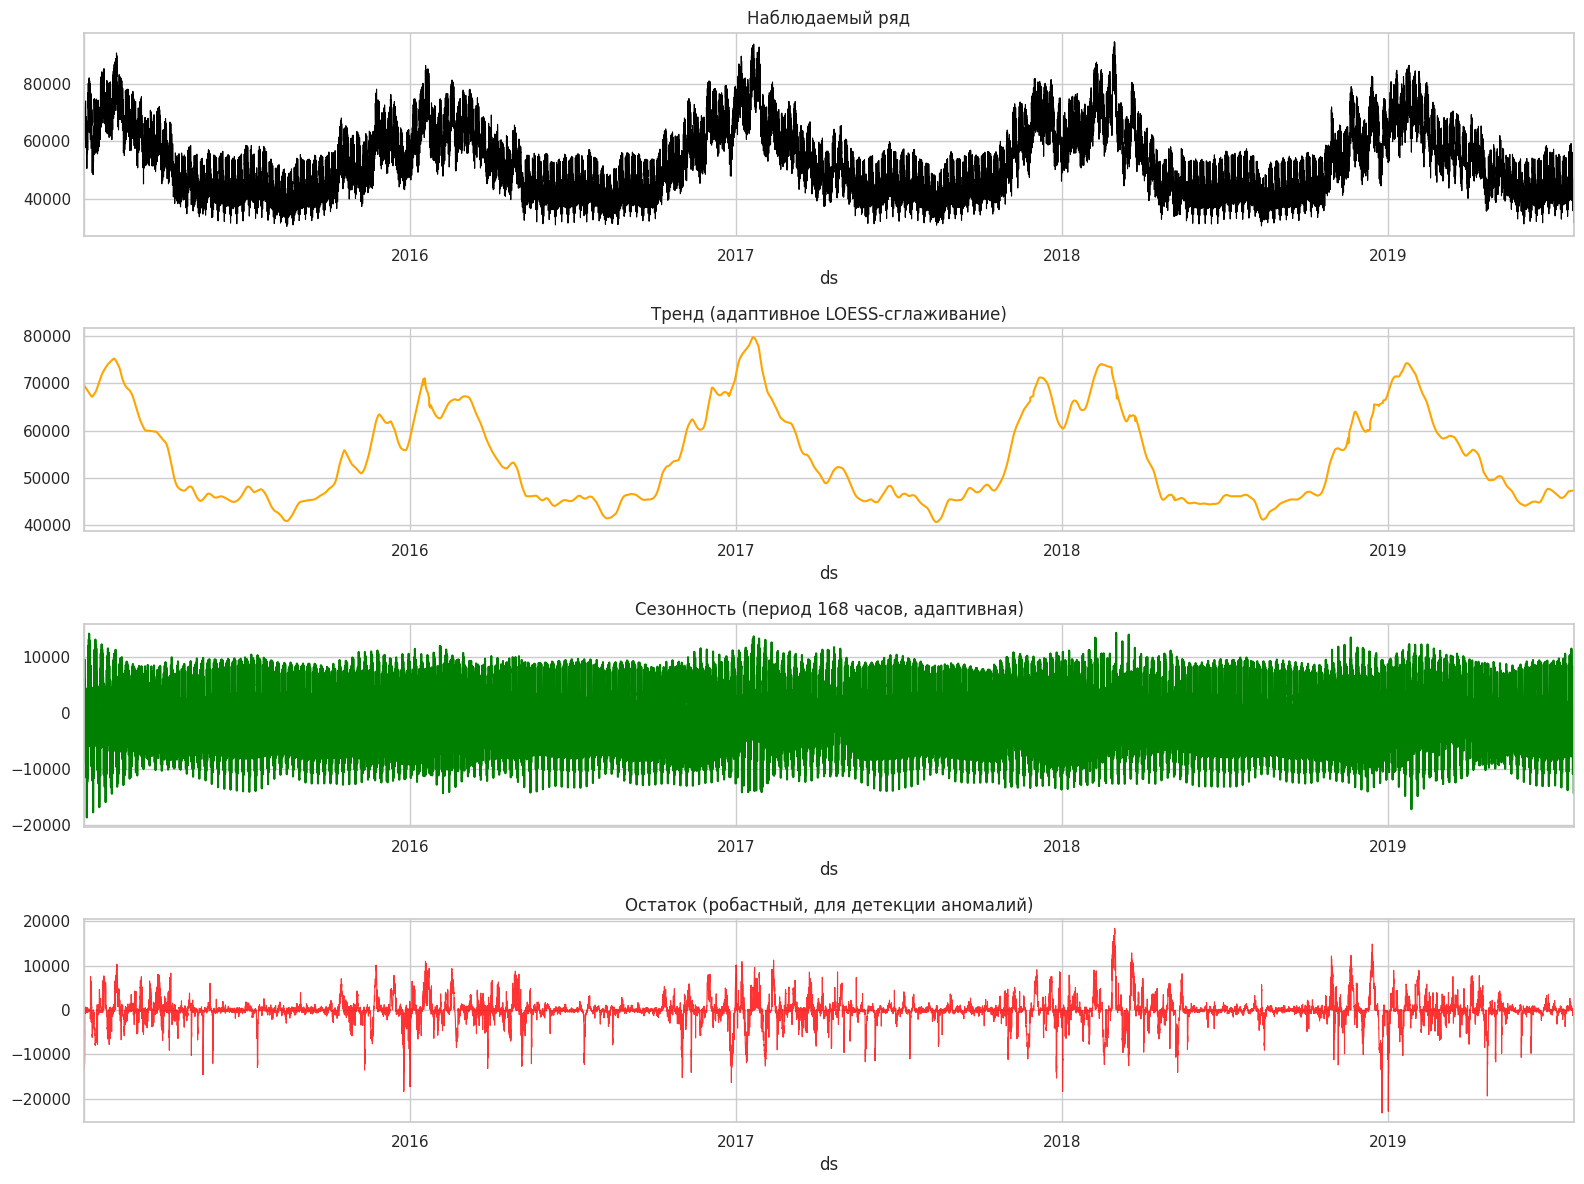

In [ ]:
# 1. Подготовка ряда: STL строго требует DatetimeIndex.
s = df.set_index(COL_DS)[COL_Y].asfreq('h')

# 2. STL декомпозиция с недельной сезонностью (168 часов) и робастной оценкой
stl = STL(s, period=24*7, robust=True)
result = stl.fit()

# 3. Визуализация
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Наблюдаемый ряд
s.plot(ax=axes[0], title="Наблюдаемый ряд", color="black", linewidth=0.8)

# Тренд
result.trend.plot(ax=axes[1], title="Тренд (адаптивное LOESS-сглаживание)", color="orange", linewidth=1.5)

# Сезонность
result.seasonal.plot(ax=axes[2], title="Сезонность (период 168 часов, адаптивная)", color="green", linewidth=1.5)

# Остаток
result.resid.plot(ax=axes[3], title="Остаток (робастный, для детекции аномалий)", color="red", linewidth=0.8, alpha=0.8)

# 4. Сохранение и отображение
plt.tight_layout()
plt.savefig(f"{DIR_TASK1}/04_decomposition_stl.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

**STL-декомпозиция ряда (период = 168 часов, робастная оценка):**

- Наблюдаемый ряд: часовые данные с выраженной волатильностью и повторяющимися паттернами.
Тренд (LOESS): долгосрочного восходящего/нисходящего тренда нет — ряд стационарен по уровню. Однако видны устойчивые годовые колебания: пики зимой (70–80 тыс. МВт), провалы летом (40–45 тыс. МВт).

- Сезонность (недельная, 168 ч): чёткий внутри недельный паттерн с амплитудой ≈ ±15 000 МВт. Амплитуда сезонности стабильна во времени → аддитивная модель сезонности уместна.

- Остаток: в основном сосредоточен около нуля, но присутствуют редкие выбросы (до ±20 000 МВт), особенно в 2017–2018 гг. — кандидаты для детекции аномалий.

Ряд содержит сильную недельную и годовую сезонность без выраженного тренда. Для базовых статистических моделей (ARIMA/ETS) необходимо учесть сезонность (SARIMA, TBATS) или явно декомпозировать ряд. Выбросы в остатке требуют отдельной обработки перед обучением ML/DL моделей.

Аномалий (скользящий IQR): 806


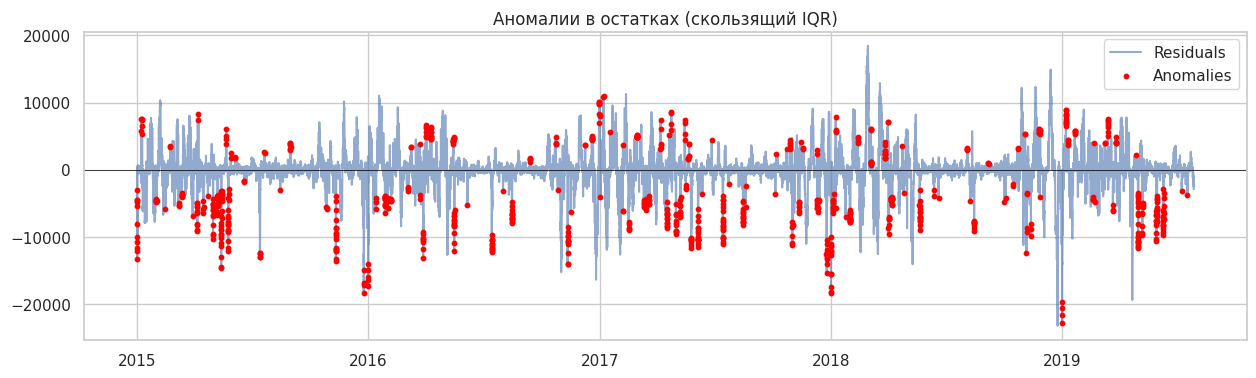

In [ ]:
# STL декомпозиция
s = df.set_index(COL_DS)[COL_Y].asfreq('h')
stl = STL(s, period=168, robust=True)
result = stl.fit()
resid = result.resid.dropna()

# СКОЛЬЗЯЩИЙ IQR (окно 168 часов = 1 неделя)
window = 168
resid_rolling = resid.rolling(window=window, center=True, min_periods=window//2)

Q1 = resid_rolling.quantile(0.25)
Q3 = resid_rolling.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3.0 * IQR
upper = Q3 + 3.0 * IQR

# Аномалии — где остаток выходит за границы скользящего IQR
anomalies_mask = (resid < lower) | (resid > upper)
anomalies_idx = resid[anomalies_mask].index

print(f"Аномалий (скользящий IQR): {len(anomalies_idx)}")

# Визуализация
plt.figure(figsize=(15, 4))
plt.plot(resid.index, resid, label='Residuals', alpha=0.6)
plt.scatter(anomalies_idx, resid[anomalies_idx], color='red', s=10, label='Anomalies', zorder=5)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title("Аномалии в остатках (скользящий IQR)")
plt.legend()
plt.savefig(f"{DIR_TASK1}/05_anomalies_train.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

**Параметры метода:**
- Окно: 168 часов (1 неделя), центрированное
- Порог: Q1/Q3 ± 3.0 × IQR (адаптивные границы)
- Обнаружено аномалий: 806 точек (~2.0% от train-выборки)

**Интерпретация:**
- Аномалии распределены неравномерно: наблюдаются кластеры в периоды резких изменений нагрузки (зима 2015, 2017, 2018–2019)
- Экстремальные выбросы достигают ±20 000 МВт — это может соответствовать аномальным погодным условиям, праздникам или ошибкам измерения
- Большинство аномалий — отрицательные (недооценка фактической нагрузки моделью STL)

Период аномалий: 2015-01-01 06:00:00+00:00 — 2019-07-18 09:00:00+00:00

Статистика аномалий:
count      806.000000
mean     52214.581472
std      11619.058193
min      32058.000000
25%      43228.750000
50%      49405.000000
75%      59530.500000
max      85843.000000
Name: y, dtype: float64

Статистика всего ряда:
count    40064.000000
mean     54196.930711
std      11704.983910
min      30426.000000
25%      45394.000000
50%      52507.500000
75%      62296.000000
max      94492.000000
Name: y, dtype: float64


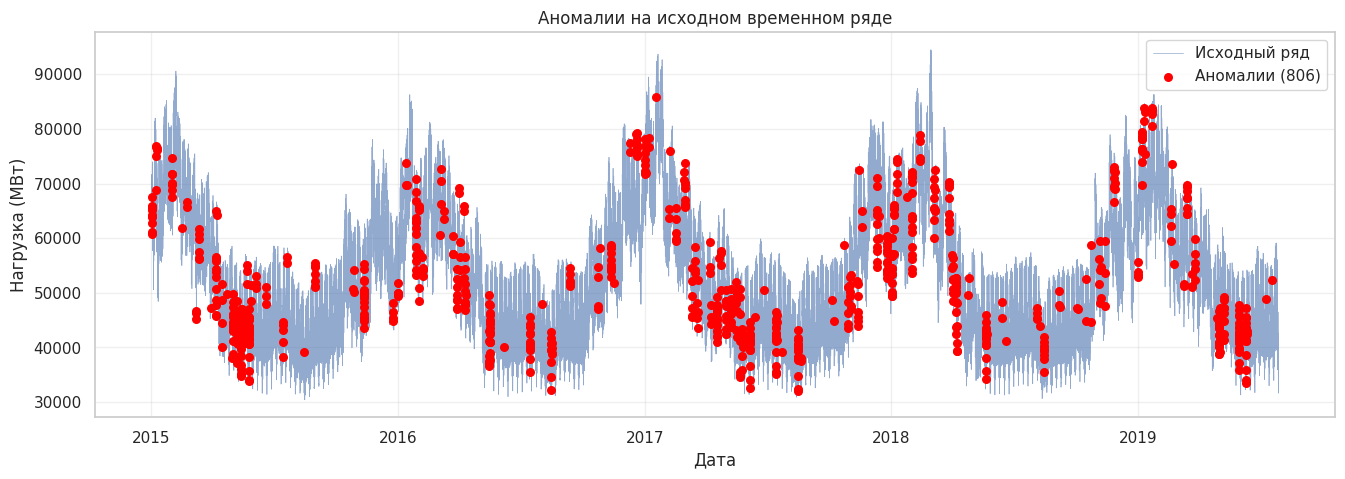

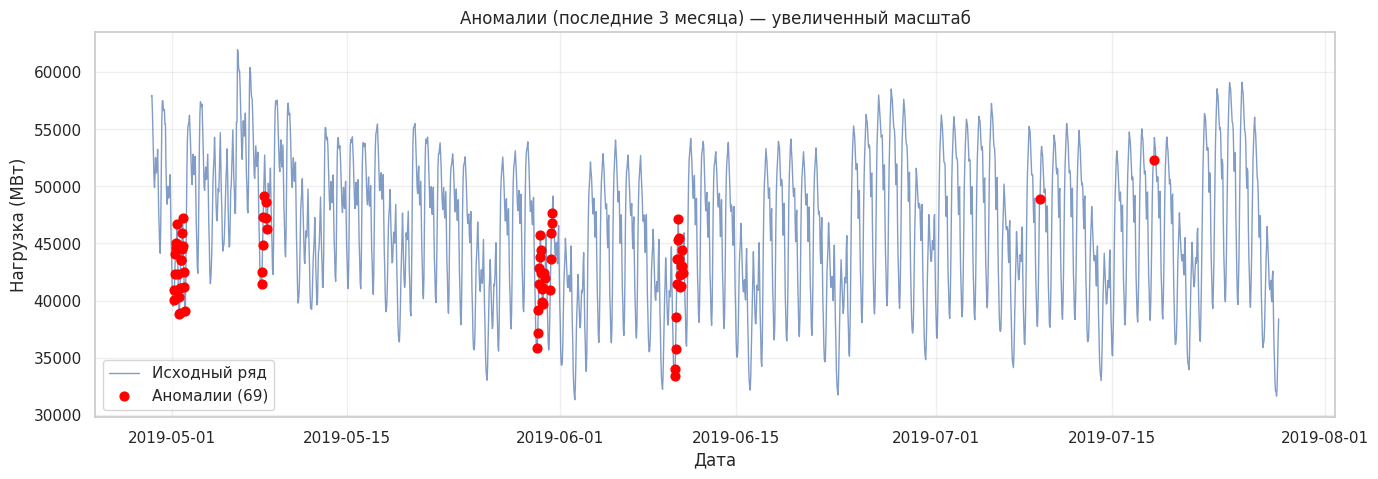

In [ ]:
# Создаём DataFrame с аномалиями для удобства
anomalies_df = df[df[COL_DS].isin(anomalies_idx)].copy()

print(f"Период аномалий: {anomalies_df[COL_DS].min()} — {anomalies_df[COL_DS].max()}")
print(f"\nСтатистика аномалий:")
print(anomalies_df[COL_Y].describe())

print(f"\nСтатистика всего ряда:")
print(df[COL_Y].describe())

# Визуализация на исходном ряде
plt.figure(figsize=(16, 5))
plt.plot(df[COL_DS], df[COL_Y], label='Исходный ряд', alpha=0.6, linewidth=0.5)
plt.scatter(anomalies_df[COL_DS], anomalies_df[COL_Y],
           color='red', s=30, label=f'Аномалии ({len(anomalies_df)})', zorder=5)
plt.title("Аномалии на исходном временном ряде")
plt.xlabel("Дата")
plt.ylabel("Нагрузка (МВт)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{DIR_TASK1}/06.1_anomalies_train_deep.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Увеличенный фрагмент (последние 3 месяца)
recent_mask = df[COL_DS] > df[COL_DS].max() - pd.Timedelta(days=90)
anomalies_recent = anomalies_df[anomalies_df[COL_DS] > df[COL_DS].max() - pd.Timedelta(days=90)]

plt.figure(figsize=(16, 5))
plt.plot(df.loc[recent_mask, COL_DS], df.loc[recent_mask, COL_Y],
         label='Исходный ряд', alpha=0.7, linewidth=1)
plt.scatter(anomalies_recent[COL_DS], anomalies_recent[COL_Y],
           color='red', s=40, label=f'Аномалии ({len(anomalies_recent)})', zorder=5)
plt.title("Аномалии (последние 3 месяца) — увеличенный масштаб")
plt.xlabel("Дата")
plt.ylabel("Нагрузка (МВт)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{DIR_TASK1}/06.2_anomalies_train_deep.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

**Характер аномалий:**
- Аномалии кластеризуются — возникают группами по несколько часов/дней
- Встречаются как на пиках нагрузки (до 85 843 МВт), так и в провалах (до 32 058 МВт)
- Среднее значение аномалий (52 215 МВт) близко к общей медиане ряда → метод детектирует отклонения в обе стороны

**Визуальный анализ (zoom за 3 месяца):**
- Аномалии часто соответствуют нехарактерным провалам в периоды ожидаемого пика
- Единичные выбросы на пиках могут соответствовать экстремальным погодным условиям или праздничным дням

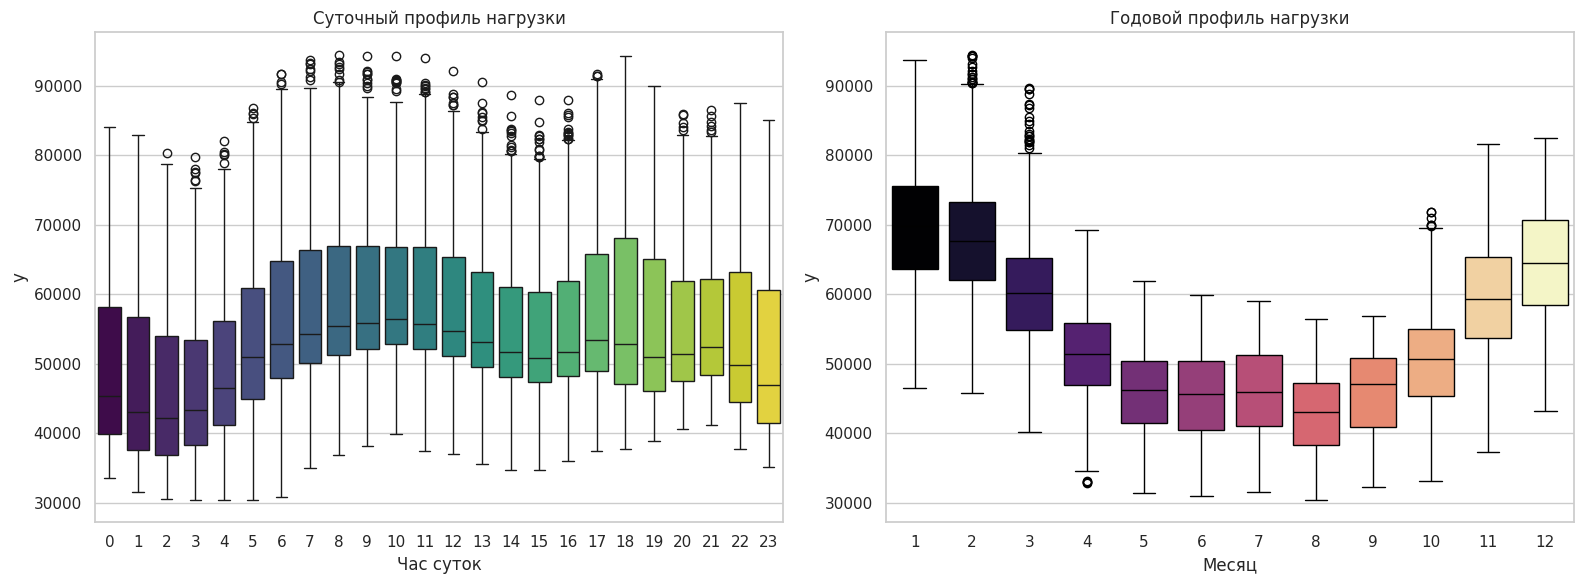

In [ ]:
# 1.3.4. Суточная и годовая сезонность
df_ = df.copy()
df_ = df_.set_index(COL_DS)
df_["hour"] = df_.index.hour
df_["month"] = df_.index.month

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Суточная
sns.boxplot(x="hour", y=COL_Y, data=df_, hue="hour", ax=axes[0], legend=False, palette="viridis")
axes[0].set_title("Суточный профиль нагрузки")
axes[0].set_xlabel("Час суток")

# Годовая
sns.boxplot(x="month", y=COL_Y, data=df_, hue="month", ax=axes[1], legend=False, palette="magma")
axes[1].set_title("Годовой профиль нагрузки")
axes[1].set_xlabel("Месяц")

plt.tight_layout()
plt.savefig(f"{DIR_TASK1}/07_seasonality_profiles.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

**Суточный профиль (левый график):**
- Ночной минимум: 02:00–05:00 (медиана ~38–42 тыс. МВт)
- Утренний рост: с 06:00, пик 08:00–11:00 (~65–67 тыс. МВт)
- Вечерний пик: 18:00–19:00 (максимальная медиана ~68 тыс. МВт)
- Размах: амплитуда суточных колебаний ≈ 25–30 тыс. МВт
- Волатильность: максимальная в часы пик (выбросы до 90+ тыс. МВт)

**Годовой профиль (правый график):**
- Зимний максимум: январь–февраль, декабрь (медиана 65–70 тыс. МВт, выбросы >90 тыс. МВт)
- Летний минимум: июнь–август (медиана 42–50 тыс. МВт)
- Межсезонье: апрель–май, сентябрь–октябрь (промежуточные значения)
- Октябрь: аномалия — резкий рост нагрузки после летнего минимума

## 1.4 ПРОВЕРКА СТАЦИОНАРНОСТИ


--- Тесты стационарности: Исходный ряд ---
ADF Statistic: -7.4345, p-value: 6.2352e-11
KPSS Statistic: 0.4108, p-value: 7.2502e-02

--- Тесты стационарности: После сезонного дифференцирования (lag=24) ---
ADF Statistic: -27.2581, p-value: 0.0000e+00
KPSS Statistic: 0.0106, p-value: 1.0000e-01


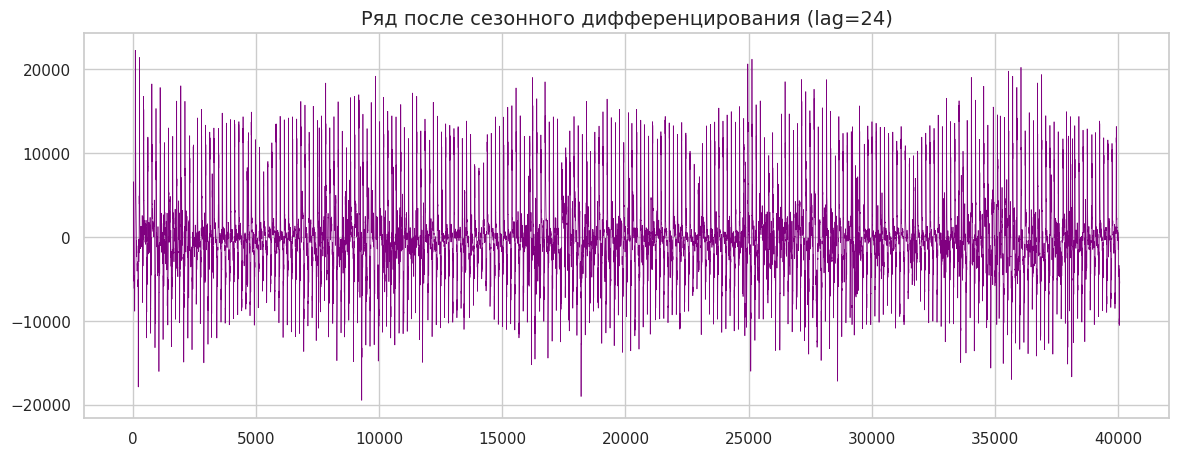

In [ ]:
def check_stationarity(series, name="Ряд"):
    # ADF Test (Null Hypothesis: Нестационарен)
    adf_result = adfuller(series.dropna())
    # KPSS Test (Null Hypothesis: Стационарен)
    kpss_result = kpss(series.dropna(), regression="c")

    print(f"\n--- Тесты стационарности: {name} ---")
    print(f"ADF Statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4e}")
    print(f"KPSS Statistic: {kpss_result[0]:.4f}, p-value: {kpss_result[1]:.4e}")

check_stationarity(df[COL_Y], "Исходный ряд")

# Сезонное дифференцирование (лаг = 24 часа)
df["load_diff_24"] = df[COL_Y].diff(24)
check_stationarity(df["load_diff_24"].dropna(), "После сезонного дифференцирования (lag=24)")

# График дифференцирования
plt.figure(figsize=(14, 5))
plt.plot(df.index[24:], df["load_diff_24"].dropna(), color="purple", linewidth=0.5)
plt.title("Ряд после сезонного дифференцирования (lag=24)", fontsize=14)
plt.savefig(f"{DIR_TASK1}/08_differencing.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

- Суточная сезонность устранена — колебания центрированы около нуля
- Амплитуда остаточных колебаний ≈ ±15 000 МВт
- Сохраняется годовая модуляция дисперсии (гетероскедастичность): зимой разброс больше, летом меньше → ряд не является слабо стационарным в строгом смысле

## 1.5 АВТОКОРРЕЛЯЦИЯ (ACF / PACF)

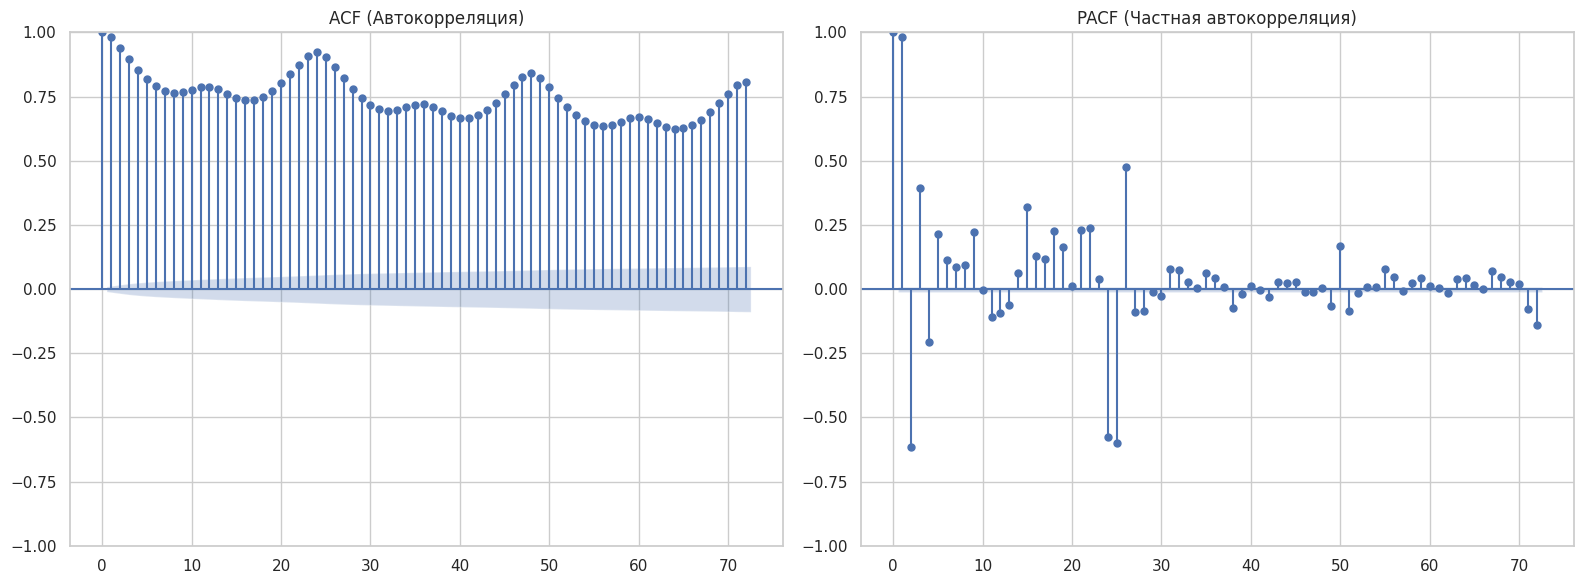

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(df[COL_Y].dropna(), lags=72, ax=axes[0], title="ACF (Автокорреляция)")
plot_pacf(df[COL_Y].dropna(), lags=72, ax=axes[1], title="PACF (Частная автокорреляция)")
plt.tight_layout()
plt.savefig(f"{DIR_TASK1}/09_acf_pacf.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

**ACF (автокорреляция):**
- Медленное синусоидальное затухание с чёткими пиками на лагах 24, 48, 72 → подтверждение сильной суточной сезонности (S=24)
- Высокие значения (~0.75–0.90) на сезонных лагах указывают на необходимость сезонного дифференцирования
- ACF не обрезается → ряд нестационарен по сезонной компоненте

**PACF (частная автокорреляция):**
- Резкий спад после лага 0
- Значимые пики: лаг 1, 2 (краткосрочная AR-зависимость) и лаг 24, 25 (сезонная AR-компонента)
- После лага ~30 значения в пределах доверительного интервала

## 1.6 FEATURE ENGINEERING (Дополнительно)

Проведём FEATURE ENGINEERING, который возможно пригодится нам для статестических моделей, а также ML/DL.

In [ ]:
df = df.set_index(COL_DS)
df_tr = df[[COL_Y]].copy()

In [ ]:
# 1.6.1. Временные признаки
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["month"] = df.index.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    return df

In [ ]:
# 1.6.2. Циклические признаки (Sin/Cos encoding)
def add_calendar_features_sin_cos(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df

In [ ]:
# 1.6.3. Лаговые признаки (Lags)
def add_lags(df: pd.DataFrame) -> pd.DataFrame:
  df = df.copy()

  for lag in LAGS:
      df[f"lag_{lag}"] = df[COL_Y].shift(lag)

  return df

In [ ]:
# 1.6.4. Скользящие статистики (Rolling features)
def add_rolling(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for roll in ROLLS:
      df[f"roll_mean_{roll}"] = df[COL_Y].rolling(window=roll).mean()

    df[f"roll_std_{ROLLS[0]}"] = df[COL_Y].rolling(window=ROLLS[0]).std()

    return df

In [ ]:
df_tr = add_calendar_features(df_tr)
df_tr = add_calendar_features_sin_cos(df_tr)
df_tr = add_lags(df_tr)
df_tr = add_rolling(df_tr)

# Удаляем NaN, возникшие из-за shift и rolling
train = df_tr.dropna().copy()

print(f"Итоговый размер датасета с признаками: {train.shape}")

# Сохраняем подготовленный датасет
train.to_csv(f"{DIR_TASK1}/train.csv")

print(f"train.csv сохранен в папку '{DIR_TASK1}/'")

train.head()

Итоговый размер датасета с признаками: (39896, 16)
train.csv сохранен в папку 'task1_outputs/'


,y,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,month_sin,month_cos,lag_1,lag_24,lag_48,lag_168,roll_mean_24,roll_mean_168,roll_std_24
ds,,,,,,,,,,,,,,,,
2015-01-08 01:00:00+00:00,64676.0,1,3,1,0,0.258819,0.965926,0.5,0.866025,65948.0,66393.0,66811.0,69773.0,73511.708333,67914.946429,5870.788788
2015-01-08 02:00:00+00:00,61551.0,2,3,1,0,0.500000,0.866025,0.5,0.866025,64676.0,63640.0,64040.0,66417.0,73424.666667,67885.982143,6036.655392
2015-01-08 03:00:00+00:00,60541.0,3,3,1,0,0.707107,0.707107,0.5,0.866025,61551.0,62955.0,63275.0,64182.0,73324.083333,67864.309524,6235.522118
2015-01-08 04:00:00+00:00,62833.0,4,3,1,0,0.866025,0.500000,0.5,0.866025,60541.0,65636.0,65977.0,63859.0,73207.291667,67858.202381,6409.601381
2015-01-08 05:00:00+00:00,68782.0,5,3,1,0,0.965926,0.258819,0.5,0.866025,62833.0,71516.0,72092.0,63921.0,73093.375000,67887.136905,6465.023143


В рамках первой задачи мы провели полный цикл первичной обработки, исследования (EDA) и генерации признаков для часового временного ряда фактической нагрузки энергосистемы Франции (2015–2020 гг.).

**Ключевые выводы по данным (EDA):**

- Качество данных: Изначальный ряд содержал 44 пропуска (успешно интерполированы) и один грубый артефактный выброс (~158,000 МВт в 2020 году), который был удален, так как не отражал реальных физических процессов.
- Трендовая составляющая: Глобальный линейный тренд отсутствует. Ряд стационарен по уровню, что упрощает задачу прогнозирования, но требует учета сложных сезонных паттернов.
- Сезонность: Ряд обладает сложной иерархической сезонностью:
  - Суточная (24 часа): Два выраженных пика (утренний и вечерний) и ночной провал.
  - Недельная (168 часов): Четкое разделение на будни (высокая нагрузка) и выходные (спад).
  - Годовая: Выраженный зимний максимум (из-за преобладания электроотопления во Франции) и летний минимум.
- Аномалии: С помощью STL-декомпозиции и метода скользящего IQR по остаткам было обнаружено 806 аномалий (~2% от train-выборки). Они кластеризуются во времени и чаще представляют собой резкие провалы или скачки, связанные с аномальными погодными условиями или спецификой праздничных дней.

**Feature Engineering:**

Для подготовки к машинному обучению был сформирован мощный набор признаков, учитывающий специфику энергетических данных:
- Календарные признаки: hour, dayofweek, month, is_weekend.
- Циклические признаки (Sin/Cos encoding): hour_sin/cos, month_sin/cos — позволяют моделям корректно воспринимать цикличность (например, что 23 часа и 1 час находятся рядом).
- Лаговые признаки (Lags): lag_1, lag_24, lag_48, lag_168 — учитывают инерционность нагрузки (предыдущий час, аналогичный час вчера, позавчера и неделю назад).
- Скользящие статистики (Rolling): roll_mean_24, roll_mean_168, roll_std_24 — сглаживают шум и задают моделям тренд/базовую линию на последние сутки и неделю.

**Разделение выборки:**

Разделение на Train (80%) и Test (20%) выполнено строго хронологически, что исключает утечку будущего (look-ahead bias) и корректно имитирует реальный процесс прогнозирования.